# Life Expectancy Prediction Using Linear Regression and PCA

## 1. Project Overview
This project predicts life expectancy using socioeconomic, mortality, health, and vaccination-related variables. The main goal is to compare a selected-feature linear regression model against a PCA-based regression model, focusing on predictive accuracy, cross-validation stability, and dimensionality reduction.

# Imports

In [61]:
# Imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Plot settings
os.makedirs("figures", exist_ok=True)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.autolayout"] = True

In [7]:
# A helper RMSE Function for future use
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 2. Dataset Description
The dataset contains 2,928 observations and 22 variables. The target variable is life_expectancy. The predictors include demographic, mortality, disease, economic, healthcare, physical health, and vaccination-related variables.

In [8]:
file_path = "data/life_expectancy.csv"

In [9]:
raw_df = pd.read_csv(file_path)
raw_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,NaN,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,NaN,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,NaN,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,NaN,NaN,18.2,18.2,0.454,9.5


In [10]:
print("Shape of raw dataset:", raw_df.shape)
print("\nColumn names:")
print(list(raw_df.columns))

Shape of raw dataset: (2928, 22)

Column names:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [11]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928 entries, 0 to 2927
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2928 non-null   object 
 1   Year                             2928 non-null   int64  
 2   Status                           2928 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2407 non-null   float64
 5   infant deaths                    2928 non-null   int64  
 6   Alcohol                          2735 non-null   float64
 7   percentage expenditure           1754 non-null   float64
 8   Hepatitis B                      2375 non-null   float64
 9   Measles                          2928 non-null   int64  
 10   BMI                             2616 non-null   float64
 11  under-five deaths                2928 non-null   int64  
 12  Polio               

In [12]:
raw_df.isna().sum().sort_values(ascending=False)

Population                         1850
GDP                                1284
percentage expenditure             1174
Hepatitis B                         553
Adult Mortality                     521
 BMI                                312
Income composition of resources     290
Total expenditure                   226
Alcohol                             193
Schooling                           160
 thinness  1-19 years                32
 thinness 5-9 years                  32
Diphtheria                           19
Polio                                19
infant deaths                         0
Life expectancy                       0
Status                                0
Year                                  0
Country                               0
Measles                               0
under-five deaths                     0
 HIV/AIDS                             0
dtype: int64

## 3. Initial Data Quality Checks
Before modeling, I checked column formatting, missing values, categorical variables, and the structure of yearly observations by country.

In [13]:
def reshaped_dataset(file_path):
    df = pd.read_csv(file_path).copy()
    df.columns = (df.columns.str.strip().str.replace(" ", "_", regex=False).str.replace(r"[/\-]", "_", regex=True).str.lower())
    # Drop rows where target is missing
    if "life_expectancy" not in df.columns:
        raise ValueError("Column 'life_expectancy' not found after cleaning column names.")

    df = df.dropna(subset=["life_expectancy"]).copy()

    return df

In [14]:
df = reshaped_dataset(file_path)

print("Cleaned dataset shape:", df.shape)
print("\nCleaned columns:")
print(list(df.columns))

Cleaned dataset shape: (2928, 22)

Cleaned columns:
['country', 'year', 'status', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness__1_19_years', 'thinness_5_9_years', 'income_composition_of_resources', 'schooling']


In [15]:
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,NaN,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,NaN,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,NaN,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,NaN,NaN,18.2,18.2,0.454,9.5


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928 entries, 0 to 2927
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2928 non-null   object 
 1   year                             2928 non-null   int64  
 2   status                           2928 non-null   object 
 3   life_expectancy                  2928 non-null   float64
 4   adult_mortality                  2407 non-null   float64
 5   infant_deaths                    2928 non-null   int64  
 6   alcohol                          2735 non-null   float64
 7   percentage_expenditure           1754 non-null   float64
 8   hepatitis_b                      2375 non-null   float64
 9   measles                          2928 non-null   int64  
 10  bmi                              2616 non-null   float64
 11  under_five_deaths                2928 non-null   int64  
 12  polio               

In [17]:
df.isna().sum().sort_values(ascending=False)

population                         1850
gdp                                1284
percentage_expenditure             1174
hepatitis_b                         553
adult_mortality                     521
bmi                                 312
income_composition_of_resources     290
total_expenditure                   226
alcohol                             193
schooling                           160
thinness__1_19_years                 32
thinness_5_9_years                   32
diphtheria                           19
polio                                19
infant_deaths                         0
life_expectancy                       0
status                                0
year                                  0
country                               0
measles                               0
under_five_deaths                     0
hiv_aids                              0
dtype: int64

In [18]:
if "status" in df.columns:
    print(df["status"].value_counts(dropna=False))
else:
    print("'status' column not found.")

status
Developing    2400
Developed      528
Name: count, dtype: int64


In [19]:
if "country" in df.columns and "year" in df.columns:
    country_counts = df.groupby("country")["year"].count().sort_values()
    print(country_counts.head(10))
    print("\nSmallest number of yearly observations for a country:", country_counts.min())
    print("Largest number of yearly observations for a country:", country_counts.max())
else:
    print("Need both 'country' and 'year' columns for this check.")

country
Afghanistan            16
Albania                16
Algeria                16
Angola                 16
Antigua and Barbuda    16
Argentina              16
Armenia                16
Australia              16
Austria                16
Azerbaijan             16
Name: year, dtype: int64

Smallest number of yearly observations for a country: 16
Largest number of yearly observations for a country: 16


In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,2928,183,Afghanistan,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2928.0,NaN,NaN,NaN,2007.5,4.61056,2000.0,2003.75,2007.5,2011.25,2015.0
status,2928,2,Developing,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
life_expectancy,2928.0,NaN,NaN,NaN,69.224932,9.523867,36.3,63.1,72.1,75.7,89.0
adult_mortality,2407.0,NaN,NaN,NaN,195.907354,115.381611,49.0,117.0,166.0,253.5,723.0
infant_deaths,2928.0,NaN,NaN,NaN,30.407445,118.11445,0.0,0.0,3.0,22.0,1800.0
alcohol,2735.0,NaN,NaN,NaN,4.614856,4.050749,0.01,0.905,3.77,7.715,17.87
percentage_expenditure,1754.0,NaN,NaN,NaN,1154.147507,2478.118157,0.0,20.300495,191.941529,818.277703,19479.91161
hepatitis_b,2375.0,NaN,NaN,NaN,80.960842,25.018337,1.0,77.0,92.0,97.0,99.0
measles,2928.0,NaN,NaN,NaN,2427.855874,11485.970937,0.0,0.0,17.0,362.25,212183.0


## 4. Train-Test Split
The data was split into training and testing sets before preprocessing to avoid data leakage. All imputation, scaling, and PCA transformations were fit only on the training data and then applied to the test data. I used a conservative 35% split.

In [21]:
X = df.drop(columns=["life_expectancy"]).copy()
y = df["life_expectancy"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=12345)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1903, 21)
X_test shape: (1025, 21)
y_train shape: (1903,)
y_test shape: (1025,)


In [22]:
X_train.head()

,country,year,status,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
452,Cambodia,2011,Developing,NaN,13,2.12,60.185918,88.0,722,17.0,15,87.0,5.64,88.0,0.3,882.491462,14537886.0,11.0,11.2,0.533,10.7
1411,Kyrgyzstan,2012,Developing,NaN,3,0.01,0.000000,96.0,0,42.2,4,94.0,6.97,96.0,0.1,NaN,NaN,3.2,3.3,0.638,12.3
794,Ecuador,2005,Developing,151.0,8,3.54,NaN,92.0,0,47.2,9,89.0,5.87,92.0,0.3,NaN,13735233.0,1.4,1.3,0.688,12.8
1465,Lebanon,2006,Developing,NaN,1,1.82,534.579570,78.0,956,61.4,1,75.0,8.83,78.0,0.1,5372.658990,NaN,4.7,4.6,0.733,13.2
241,Belgium,2014,Developed,76.0,0,12.60,7163.348923,98.0,70,63.4,1,99.0,1.59,99.0,0.1,47439.396840,NaN,1.0,1.0,0.890,16.3


In [23]:
y_train.head()

452     67.0
1411    69.9
794     74.2
1465    74.1
241     89.0
Name: life_expectancy, dtype: float64

## 5. Exploratory Correlation Analysis
adult_mortality, income_composition, shooling, and BMI are amonng the strongest drivers. This correlation analysis suggests multicollinearity among predictos.

In [24]:
temp_df = df.copy()

numeric_corr = temp_df.corr(numeric_only=True)["life_expectancy"].sort_values(key=lambda x: np.abs(x), ascending=False)
numeric_corr

life_expectancy                    1.000000
adult_mortality                   -0.930523
income_composition_of_resources    0.888599
schooling                          0.751975
bmi                                0.719625
gdp                                0.589772
hiv_aids                          -0.556556
percentage_expenditure             0.484147
diphtheria                         0.479495
thinness__1_19_years              -0.477183
thinness_5_9_years                -0.471584
polio                              0.465556
alcohol                            0.404877
hepatitis_b                        0.256762
under_five_deaths                 -0.222529
total_expenditure                  0.218086
infant_deaths                     -0.196557
year                               0.170033
measles                           -0.157586
population                        -0.024834
Name: life_expectancy, dtype: float64

In [25]:
numeric_corr_df = pd.DataFrame({
    "correlation_with_life_expectancy": numeric_corr,
    "abs_correlation": numeric_corr.abs()
}).sort_values("abs_correlation", ascending=False)

numeric_corr_df

,correlation_with_life_expectancy,abs_correlation
life_expectancy,1.000000,1.000000
adult_mortality,-0.930523,0.930523
income_composition_of_resources,0.888599,0.888599
schooling,0.751975,0.751975
bmi,0.719625,0.719625
gdp,0.589772,0.589772
hiv_aids,-0.556556,0.556556
percentage_expenditure,0.484147,0.484147
diphtheria,0.479495,0.479495
thinness__1_19_years,-0.477183,0.477183


## 6. Feature Selection Strategy
To reduce dimensionality and improve interpretability, I selected the predictors with the strongest absolute correlation with life expectancy. Variables with weak correlation or limited predictive contribution were excluded from the main feature sweep.

In [26]:
selected_features = ["adult_mortality", "income_composition_of_resources", "schooling", "bmi", "gdp", "hiv_aids", "percentage_expenditure", "diphtheria", "polio", "alcohol"]

## 7. Preprocessing Pipeline
This function applies:
- feature selection
- dummy encoding for categorical variables
- zero to NaN replacement
- log transformation for skewed variableds
- KNN imputation
- standard scaling
- optional PCA

In [27]:
def data_preprocessing(
    X_train,
    X_test,
    y_train,
    y_test,
    selected_features=None,
    log_features=None,
    zero_to_nan_features=None,
    imputer_k=5,
    scale=True,
    use_pca=False,
    n_components=None):
    X_train = X_train.copy()
    X_test = X_test.copy()
    y_train = y_train.copy()
    y_test = y_test.copy()

    #dummy encode
    if "status" in X_train.columns:
        X_train = pd.get_dummies(X_train, columns=["status"], drop_first=True)
        X_test = pd.get_dummies(X_test, columns=["status"], drop_first=True)

    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
    
    #feature selection
    if selected_features is not None:
        keep_cols = [col for col in selected_features if col in X_train.columns]
        # include status dummy if exists
        keep_cols += [col for col in X_train.columns if "status_" in col]

        X_train = X_train[keep_cols]
        X_test = X_test[keep_cols]
        
    #zero to NaN
    if zero_to_nan_features is not None:
        for col in zero_to_nan_features:
            if col in X_train.columns:
                X_train[col] = X_train[col].replace(0, np.nan)
            if col in X_test.columns:
                X_test[col] = X_test[col].replace(0, np.nan)

    #log transform
    if log_features is not None:
        for col in log_features:
            if col in X_train.columns:
                X_train[col] = np.log(X_train[col])
            if col in X_test.columns:
                X_test[col] = np.log(X_test[col])
                
    #KNN
    imputer = KNNImputer(n_neighbors=imputer_k, weights="distance")
    X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    #scaling
    scaler = None
    if scale:
        scaler = StandardScaler()

        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns)

        X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns)
    else:
        X_train_scaled = X_train_imputed
        X_test_scaled = X_test_imputed

    #optional PCA 
    pca_model = None
    if use_pca:
        pca_model = PCA(n_components=n_components)

        X_train_final = pca_model.fit_transform(X_train_scaled)
        X_test_final = pca_model.transform(X_test_scaled)
    else:
        X_train_final = X_train_scaled
        X_test_final = X_test_scaled

    return X_train_final, X_test_final, y_train, y_test, {"imputer": imputer, "scaler": scaler, "pca_model": pca_model}

In [28]:
zero_to_nan_features = ["gdp", "percentage_expenditure"]

log_features = ["adult_mortality", "gdp", "hiv_aids", "percentage_expenditure"]

In [29]:
X_train_prep, X_test_prep, y_train_prep, y_test_prep, prep_objects = data_preprocessing(
    X_train,
    X_test,
    y_train,
    y_test,
    selected_features=selected_features,
    log_features=log_features,
    zero_to_nan_features=zero_to_nan_features,
    scale=True,
    use_pca=False)

In [30]:
print("Shape after preprocessing:", X_train_prep.shape)
X_train_prep.head()

Shape after preprocessing: (1903, 11)


,adult_mortality,income_composition_of_resources,schooling,bmi,gdp,hiv_aids,percentage_expenditure,diphtheria,polio,alcohol,status_Developing
0,0.248830,-0.746562,-0.312287,-1.446371,-0.963497,0.003524,-1.230829,0.240072,0.199044,-0.632796,0.472237
1,-0.180181,-0.104656,0.117592,0.014388,-0.235376,-0.673425,0.178599,0.572264,0.490746,-1.159673,0.472237
2,-0.190161,0.201013,0.251929,0.304221,-0.004406,0.003524,0.146186,0.406168,0.282387,-0.278216,0.472237
3,-0.703082,0.476116,0.359399,1.127348,0.262536,-0.673425,0.148848,-0.175167,-0.301018,-0.707708,0.472237
4,-1.428409,1.435918,1.192289,1.243281,1.740925,-0.673425,1.788289,0.696836,0.699105,1.984105,-2.117581


In [31]:
pd.DataFrame(X_train_prep).isna().sum()

adult_mortality                    0
income_composition_of_resources    0
schooling                          0
bmi                                0
gdp                                0
hiv_aids                           0
percentage_expenditure             0
diphtheria                         0
polio                              0
alcohol                            0
status_Developing                  0
dtype: int64

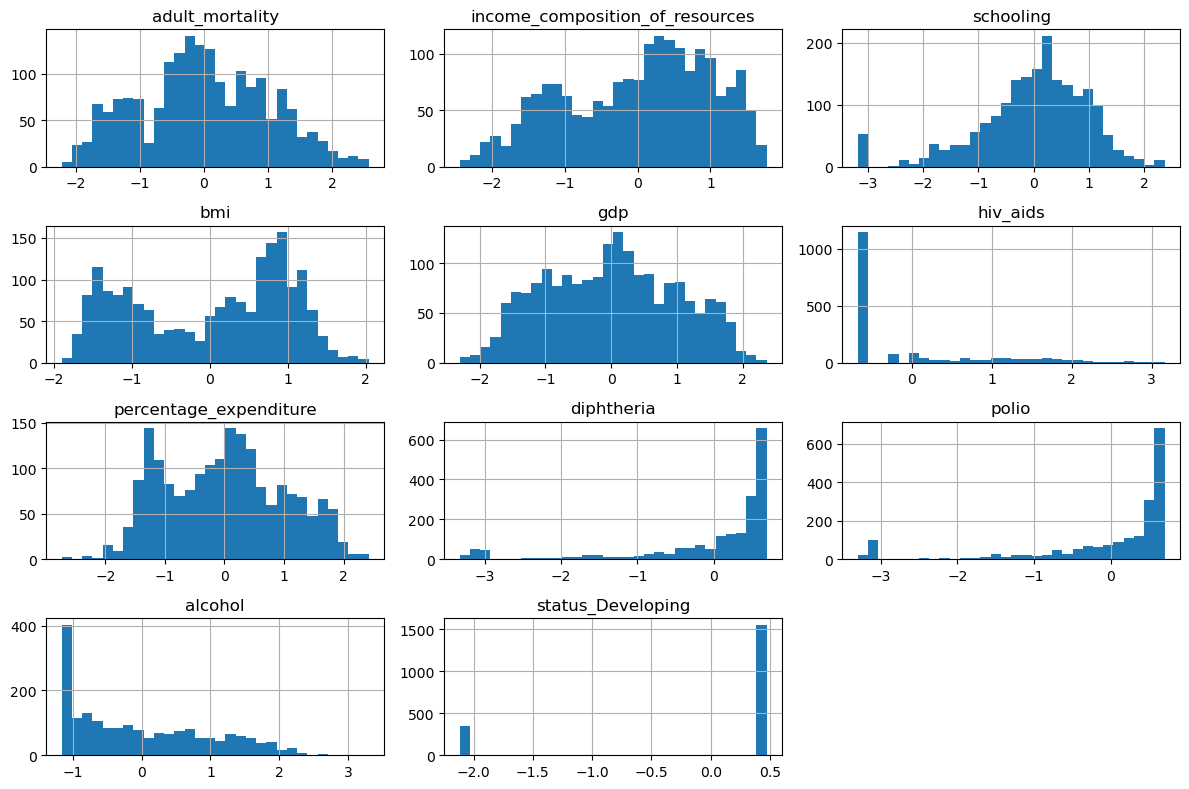

In [32]:
pd.DataFrame(X_train_prep).hist(bins=30, figsize=(12, 8))
plt.show()

## 8. Linear Regression Modeling Function
This function preprocesses the data, fits a LinearRegression model, generates predictions, and reports RMSE and R² on both training and testing data.

In [33]:
def multilinear_regression(
    X_train,
    X_test,
    y_train,
    y_test,
    selected_features,
    log_features,
    zero_to_nan_features,
    scale=True):
    #preprocess
    X_train_prep, X_test_prep, y_train_prep, y_test_prep, _ = data_preprocessing(
        X_train,
        X_test,
        y_train,
        y_test,
        selected_features=selected_features,
        log_features=log_features,
        zero_to_nan_features=zero_to_nan_features,
        scale=scale,
        use_pca=False)
    #model
    model = LinearRegression()
    model.fit(X_train_prep, y_train_prep)
    #redictions
    y_train_pred = model.predict(X_train_prep)
    y_test_pred = model.predict(X_test_prep)

    return {
        "model": model,
        "train_rmse": rmse(y_train_prep, y_train_pred),
        "test_rmse": rmse(y_test_prep, y_test_pred),
        "train_r2": r2_score(y_train_prep, y_train_pred),
        "test_r2": r2_score(y_test_prep, y_test_pred)}

In [34]:
result = multilinear_regression(
    X_train,
    X_test,
    y_train,
    y_test,
    selected_features=selected_features,
    log_features=log_features,
    zero_to_nan_features=zero_to_nan_features)
result

{'model': LinearRegression(),
 'train_rmse': np.float64(2.733153965449023),
 'test_rmse': np.float64(2.672804264143751),
 'train_r2': 0.9162734933983019,
 'test_r2': 0.9234411437879727}

## 9. Feature Sweep: Linear Regression Without PCA
Performance improved sharply when moving from 5 to 6 features, while additional features produced smaller gains. This suggested that a 6-feature model offered a strong balance between predictive performance and interpretability.

In [35]:
#ordered features based on prior correlation analysis
ordered_features = [
    "adult_mortality",
    "income_composition_of_resources",
    "schooling",
    "bmi",
    "gdp",
    "hiv_aids",
    "percentage_expenditure",
    "diphtheria",
    "polio",
    "alcohol"]

In [36]:
def evaluate_feature_subset(features, k=5, n_repeats=3):
    rkf = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)

    cv_rmse = []
    cv_r2 = []

    for train_idx, val_idx in rkf.split(X_train):
        X_subtrain = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_subtrain = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        res = multilinear_regression(
            X_subtrain,
            X_val,
            y_subtrain,
            y_val,
            selected_features=features,
            log_features=log_features,
            zero_to_nan_features=zero_to_nan_features)

        cv_rmse.append(res["test_rmse"])
        cv_r2.append(res["test_r2"])

    final_res = multilinear_regression(
        X_train,
        X_test,
        y_train,
        y_test,
        selected_features=features,
        log_features=log_features,
        zero_to_nan_features=zero_to_nan_features)

    return {
        "features": features,
        "n_features": len(features),
        "cv_rmse_mean": np.mean(cv_rmse),
        "cv_rmse_std": np.std(cv_rmse),
        "cv_r2_mean": np.mean(cv_r2),
        "cv_r2_std": np.std(cv_r2),
        "test_rmse": final_res["test_rmse"],
        "test_r2": final_res["test_r2"]}

In [37]:
results = []

for i in range(2, len(ordered_features) + 1):
    subset = ordered_features[:i]

    res = evaluate_feature_subset(subset)
    results.append(res)

results_df = pd.DataFrame(results)
results_df

,features,n_features,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_rmse,test_r2
0,"[adult_mortality, income_composition_of_resour...",2,4.010020,0.210617,0.819047,0.015115,3.956806,0.832216
1,"[adult_mortality, income_composition_of_resour...",3,3.930226,0.241897,0.826060,0.017592,3.981217,0.830139
2,"[adult_mortality, income_composition_of_resour...",4,4.069046,0.254154,0.813447,0.020269,4.208710,0.810172
3,"[adult_mortality, income_composition_of_resour...",5,4.050574,0.274560,0.815051,0.022071,4.120403,0.818055
4,"[adult_mortality, income_composition_of_resour...",6,3.070232,0.177002,0.893793,0.010710,2.972402,0.905316
5,"[adult_mortality, income_composition_of_resour...",7,3.056507,0.165953,0.894742,0.010174,2.972941,0.905282
6,"[adult_mortality, income_composition_of_resour...",8,2.887533,0.160537,0.905966,0.009836,2.796209,0.916208
7,"[adult_mortality, income_composition_of_resour...",9,2.864592,0.174560,0.907448,0.010305,2.794928,0.916285
8,"[adult_mortality, income_composition_of_resour...",10,2.763310,0.177199,0.913792,0.010637,2.672804,0.923441


In [38]:
results_df[["n_features", "cv_rmse_mean", "cv_r2_mean", "test_rmse", "test_r2"]]

,n_features,cv_rmse_mean,cv_r2_mean,test_rmse,test_r2
0,2,4.010020,0.819047,3.956806,0.832216
1,3,3.930226,0.826060,3.981217,0.830139
2,4,4.069046,0.813447,4.208710,0.810172
3,5,4.050574,0.815051,4.120403,0.818055
4,6,3.070232,0.893793,2.972402,0.905316
5,7,3.056507,0.894742,2.972941,0.905282
6,8,2.887533,0.905966,2.796209,0.916208
7,9,2.864592,0.907448,2.794928,0.916285
8,10,2.763310,0.913792,2.672804,0.923441


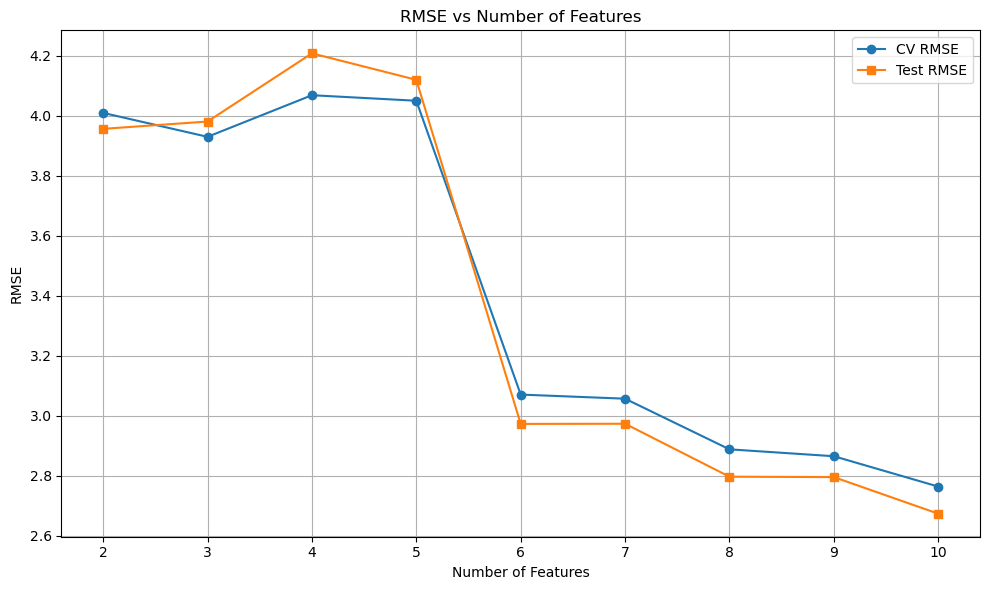

In [62]:
plt.figure()
plt.plot(results_df["n_features"], results_df["cv_rmse_mean"], marker="o", label="CV RMSE")
plt.plot(results_df["n_features"], results_df["test_rmse"], marker="s", label="Test RMSE")
plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.title("RMSE vs Number of Features")
plt.legend()
plt.grid()
plt.savefig("figures/rmse_vs_features.png", dpi=300, bbox_inches="tight")
plt.show()

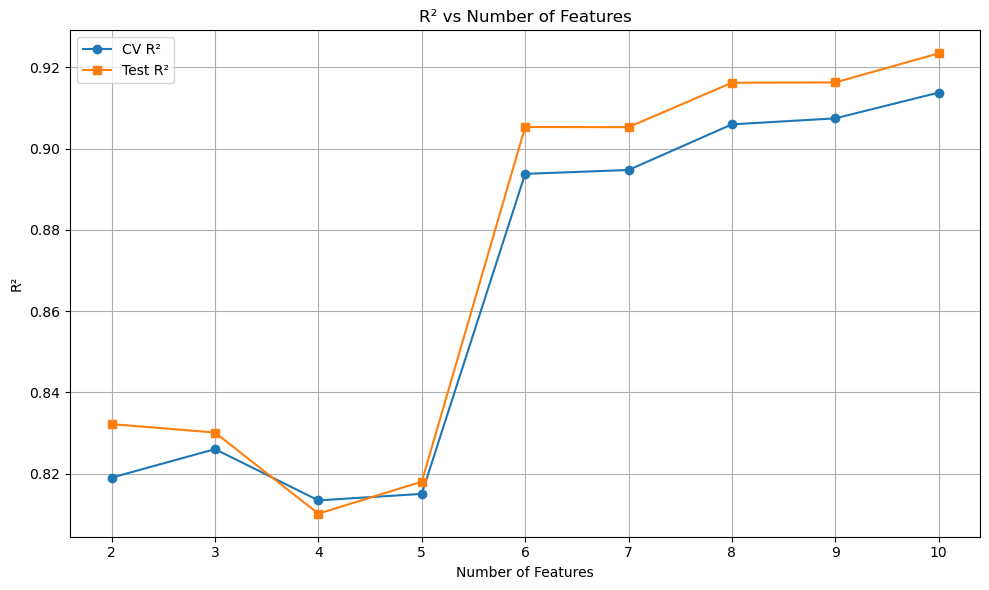

In [63]:
plt.figure()
plt.plot(results_df["n_features"], results_df["cv_r2_mean"], marker="o", label="CV R²")
plt.plot(results_df["n_features"], results_df["test_r2"], marker="s", label="Test R²")
plt.xlabel("Number of Features")
plt.ylabel("R²")
plt.title("R² vs Number of Features")
plt.legend()
plt.grid()
plt.savefig("figures/r2_vs_features.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. PCA Regression Experiment
PCA was used to transform the correlated predictors into orthogonal components. I evaluated models using 2 through 10 principal components to determine how much predictive information could be retained after dimensionality reduction.

In [41]:
def multilinear_regression_pca(
    X_train,
    X_test,
    y_train,
    y_test,
    n_components,
    log_features,
    zero_to_nan_features):
    X_train_prep, X_test_prep, y_train_prep, y_test_prep, _ = data_preprocessing(
        X_train,
        X_test,
        y_train,
        y_test,
        selected_features=ordered_features,  # use ALL 10 features
        log_features=log_features,
        zero_to_nan_features=zero_to_nan_features,
        scale=True,
        use_pca=True,
        n_components=n_components)

    model = LinearRegression()
    model.fit(X_train_prep, y_train_prep)

    y_train_pred = model.predict(X_train_prep)
    y_test_pred = model.predict(X_test_prep)

    return {"train_rmse": rmse(y_train_prep, y_train_pred), "test_rmse": rmse(y_test_prep, y_test_pred), "train_r2": r2_score(y_train_prep, y_train_pred), "test_r2": r2_score(y_test_prep, y_test_pred)}

In [42]:
def evaluate_pca_model(n_components, k=5, n_repeats=3):
    rkf = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)

    cv_rmse = []
    cv_r2 = []

    for train_idx, val_idx in rkf.split(X_train):
        X_subtrain = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_subtrain = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        res = multilinear_regression_pca(
            X_subtrain,
            X_val,
            y_subtrain,
            y_val,
            n_components=n_components,
            log_features=log_features,
            zero_to_nan_features=zero_to_nan_features)

        cv_rmse.append(res["test_rmse"])
        cv_r2.append(res["test_r2"])

    final_res = multilinear_regression_pca(
        X_train,
        X_test,
        y_train,
        y_test,
        n_components=n_components,
        log_features=log_features,
        zero_to_nan_features=zero_to_nan_features)

    return {
    "n_components": n_components,
    "cv_rmse_mean": np.mean(cv_rmse),
    "cv_rmse_std": np.std(cv_rmse),
    "cv_r2_mean": np.mean(cv_r2),
    "cv_r2_std": np.std(cv_r2),
    "test_rmse": final_res["test_rmse"],
    "test_r2": final_res["test_r2"]}

In [43]:
# Sweep
pca_results = []

for k in range(2, 11):
    res = evaluate_pca_model(k)
    pca_results.append(res)

pca_df = pd.DataFrame(pca_results)
pca_df

,n_components,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_rmse,test_r2
0,2,4.209763,0.154495,0.800577,0.012818,3.938587,0.833758
1,3,3.363446,0.124594,0.872535,0.010501,3.128531,0.895108
2,4,3.205312,0.124060,0.884164,0.010454,3.014550,0.902612
3,5,3.169487,0.120658,0.886735,0.010179,3.005430,0.903200
4,6,3.171521,0.126013,0.886573,0.010514,3.005849,0.903173
5,7,3.091609,0.142017,0.892251,0.010174,2.952952,0.906551
6,8,3.048926,0.143690,0.895245,0.009560,2.909401,0.909287
7,9,2.807401,0.168006,0.911089,0.010019,2.697140,0.922041
8,10,2.799915,0.173555,0.911550,0.010241,2.702605,0.921724


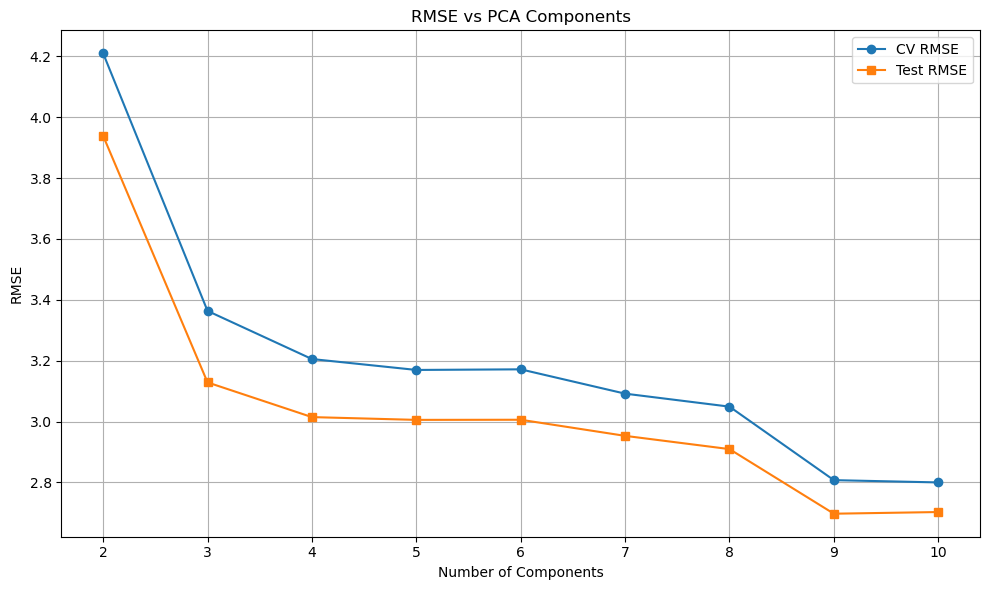

In [64]:
# Plots
plt.figure()
plt.plot(pca_df["n_components"], pca_df["cv_rmse_mean"], marker="o", label="CV RMSE")
plt.plot(pca_df["n_components"], pca_df["test_rmse"], marker="s", label="Test RMSE")
plt.xlabel("Number of Components")
plt.ylabel("RMSE")
plt.title("RMSE vs PCA Components")
plt.legend()
plt.grid()
plt.savefig("figures/rmse_vs_pca.png", dpi=300, bbox_inches="tight")
plt.show()

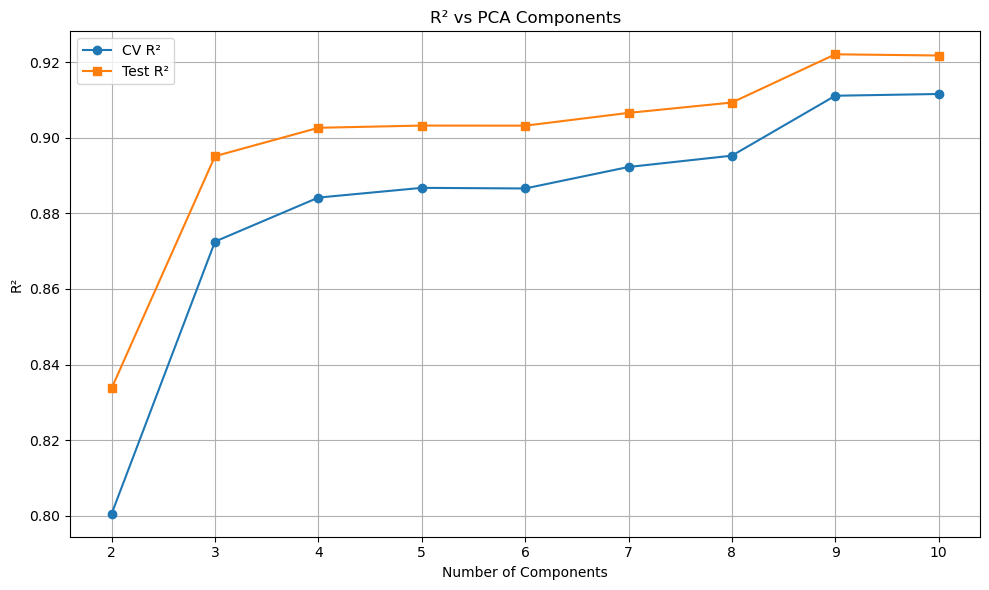

In [65]:
plt.figure()
plt.plot(pca_df["n_components"], pca_df["cv_r2_mean"], marker="o", label="CV R²")
plt.plot(pca_df["n_components"], pca_df["test_r2"], marker="s", label="Test R²")
plt.xlabel("Number of Components")
plt.ylabel("R²")
plt.title("R² vs PCA Components")
plt.legend()
plt.grid()
plt.savefig("figures/r2_vs_pca.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Optimized Linear Regression Model Without PCA
The optimized non-PCA model used six predictors: adult_mortality, income_composition_of_resources, schooling, BMI, GDP, and hiv_aids. This model provided strong predictive performance while remaining interpretable.

In [46]:
optimized_features_6 = ["adult_mortality", "income_composition_of_resources", "schooling", "bmi", "gdp", "hiv_aids"]
optimized_features_6

['adult_mortality',
 'income_composition_of_resources',
 'schooling',
 'bmi',
 'gdp',
 'hiv_aids']

In [47]:
optimized_multilinear_result = multilinear_regression(
    X_train,
    X_test,
    y_train,
    y_test,
    selected_features=optimized_features_6,
    log_features=log_features,
    zero_to_nan_features=zero_to_nan_features,
    scale=True)

optimized_multilinear_result

{'model': LinearRegression(),
 'train_rmse': np.float64(3.098824963259221),
 'test_rmse': np.float64(2.972402142513846),
 'train_r2': 0.8923711082781648,
 'test_r2': 0.9053160741120262}

In [48]:
optimized_multilinear_summary = pd.DataFrame({
    "metric": ["train_rmse", "test_rmse", "train_r2", "test_r2"],
    "value": [optimized_multilinear_result["train_rmse"], optimized_multilinear_result["test_rmse"], optimized_multilinear_result["train_r2"],
        optimized_multilinear_result["test_r2"]]})

optimized_multilinear_summary

,metric,value
0,train_rmse,3.098825
1,test_rmse,2.972402
2,train_r2,0.892371
3,test_r2,0.905316


In [49]:
optimized_6_cv_result = evaluate_feature_subset(optimized_features_6)
optimized_6_cv_result

{'features': ['adult_mortality',
  'income_composition_of_resources',
  'schooling',
  'bmi',
  'gdp',
  'hiv_aids'],
 'n_features': 6,
 'cv_rmse_mean': np.float64(3.0702319512182883),
 'cv_rmse_std': np.float64(0.17700237690432905),
 'cv_r2_mean': np.float64(0.8937925638425361),
 'cv_r2_std': np.float64(0.01071001415762254),
 'test_rmse': np.float64(2.972402142513846),
 'test_r2': 0.9053160741120262}

In [50]:
optimized_6_cv_summary = pd.DataFrame({"metric": [
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "test_rmse",
        "test_r2"],
    "value": [
        optimized_6_cv_result["cv_rmse_mean"],
        optimized_6_cv_result["cv_rmse_std"],
        optimized_6_cv_result["cv_r2_mean"],
        optimized_6_cv_result["cv_r2_std"],
        optimized_6_cv_result["test_rmse"],
        optimized_6_cv_result["test_r2"]]})
optimized_6_cv_summary

,metric,value
0,cv_rmse_mean,3.070232
1,cv_rmse_std,0.177002
2,cv_r2_mean,0.893793
3,cv_r2_std,0.010710
4,test_rmse,2.972402
5,test_r2,0.905316


In [51]:
results_df[["n_features", "cv_rmse_mean", "cv_r2_mean", "test_rmse", "test_r2"]]

,n_features,cv_rmse_mean,cv_r2_mean,test_rmse,test_r2
0,2,4.010020,0.819047,3.956806,0.832216
1,3,3.930226,0.826060,3.981217,0.830139
2,4,4.069046,0.813447,4.208710,0.810172
3,5,4.050574,0.815051,4.120403,0.818055
4,6,3.070232,0.893793,2.972402,0.905316
5,7,3.056507,0.894742,2.972941,0.905282
6,8,2.887533,0.905966,2.796209,0.916208
7,9,2.864592,0.907448,2.794928,0.916285
8,10,2.763310,0.913792,2.672804,0.923441


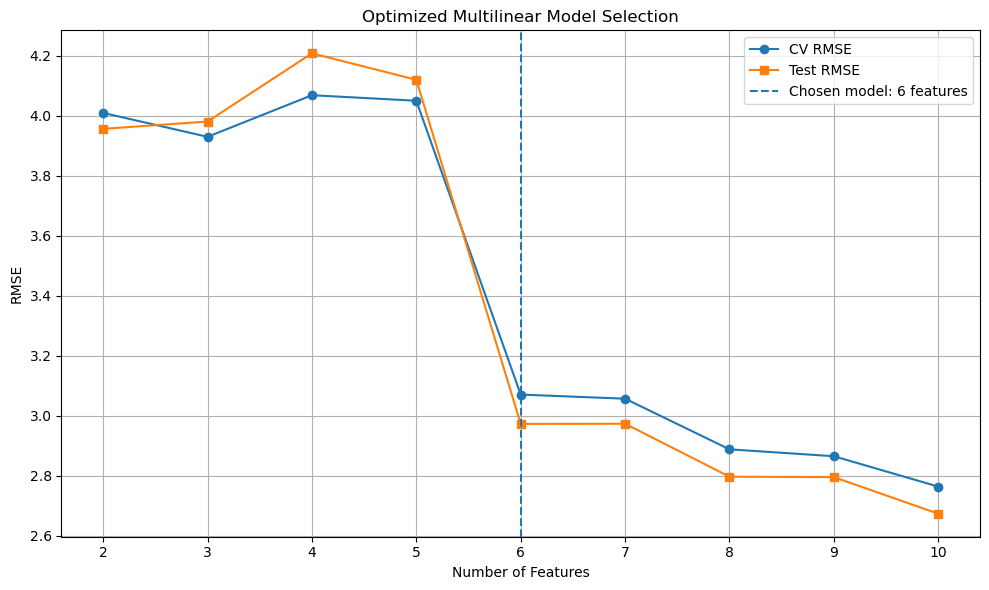

In [52]:
plt.figure()
plt.plot(results_df["n_features"], results_df["cv_rmse_mean"], marker="o", label="CV RMSE")
plt.plot(results_df["n_features"], results_df["test_rmse"], marker="s", label="Test RMSE")
plt.axvline(x=6, linestyle="--", label="Chosen model: 6 features")

plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.title("Optimized Multilinear Model Selection")
plt.legend()
plt.grid()
plt.show()

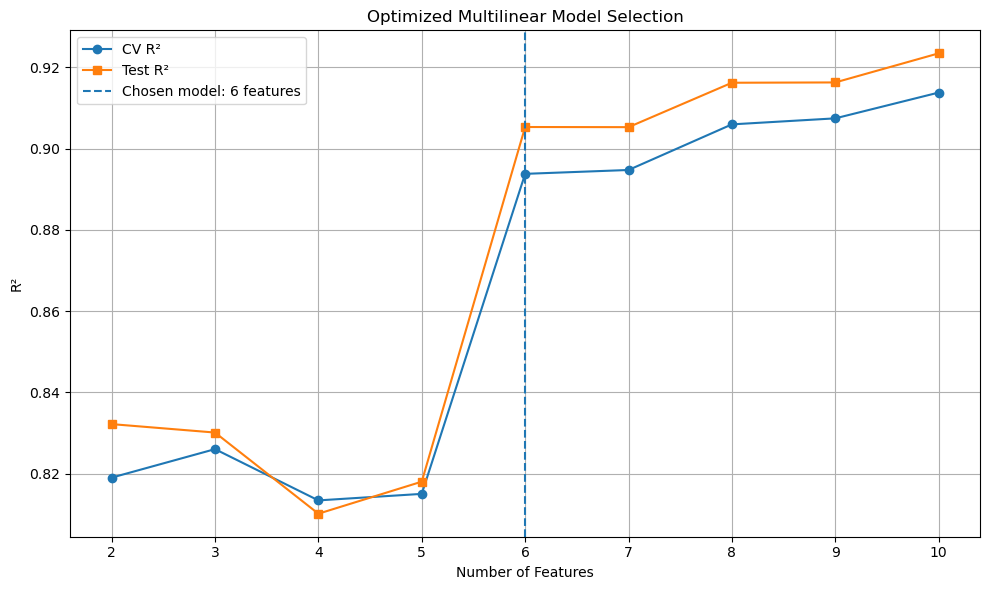

In [53]:
plt.figure()
plt.plot(results_df["n_features"], results_df["cv_r2_mean"], marker="o", label="CV R²")
plt.plot(results_df["n_features"], results_df["test_r2"], marker="s", label="Test R²")
plt.axvline(x=6, linestyle="--", label="Chosen model: 6 features")

plt.xlabel("Number of Features")
plt.ylabel("R²")
plt.title("Optimized Multilinear Model Selection")
plt.legend()
plt.grid()
plt.show()

## 12. Optimized PCA Regression Model
The optimized PCA model used 3 principal components. This model slightly reduced raw predictive accuracy but improved dimensional efficiency and reduced sensitivity to multicollinearity.

In [54]:
optimal_pca_components = 3

In [55]:
optimized_pca_result = multilinear_regression_pca(
    X_train,
    X_test,
    y_train,
    y_test,
    n_components=optimal_pca_components,
    log_features=log_features,
    zero_to_nan_features=zero_to_nan_features)

optimized_pca_result

{'train_rmse': np.float64(3.3390719677796374),
 'test_rmse': np.float64(3.128531401038766),
 'train_r2': 0.87503559210672,
 'test_r2': 0.8951080492998927}

In [56]:
optimized_pca_summary = pd.DataFrame({
    "metric": ["train_rmse", "test_rmse", "train_r2", "test_r2"],
    "value": [
        optimized_pca_result["train_rmse"],
        optimized_pca_result["test_rmse"],
        optimized_pca_result["train_r2"],
        optimized_pca_result["test_r2"]]})

optimized_pca_summary

,metric,value
0,train_rmse,3.339072
1,test_rmse,3.128531
2,train_r2,0.875036
3,test_r2,0.895108


In [57]:
print("Optimized PCA model (3 components)")
print(f"Train RMSE: {optimized_pca_result['train_rmse']:.4f}")
print(f"Test RMSE : {optimized_pca_result['test_rmse']:.4f}")
print(f"Train R^2 : {optimized_pca_result['train_r2']:.4f}")
print(f"Test R^2  : {optimized_pca_result['test_r2']:.4f}")

Optimized PCA model (3 components)
Train RMSE: 3.3391
Test RMSE : 3.1285
Train R^2 : 0.8750
Test R^2  : 0.8951


In [58]:
optimized_pca_cv_result = evaluate_pca_model(optimal_pca_components)
optimized_pca_cv_result

{'n_components': 3,
 'cv_rmse_mean': np.float64(3.3634458646119034),
 'cv_rmse_std': np.float64(0.12459395973324622),
 'cv_r2_mean': np.float64(0.8725354525541278),
 'cv_r2_std': np.float64(0.010501114206074434),
 'test_rmse': np.float64(3.128531401038766),
 'test_r2': 0.8951080492998927}

In [59]:
optimized_pca_cv_summary = pd.DataFrame({
    "metric": [
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "test_rmse",
        "test_r2"],
    "value": [
        optimized_pca_cv_result["cv_rmse_mean"],
        optimized_pca_cv_result["cv_rmse_std"],
        optimized_pca_cv_result["cv_r2_mean"],
        optimized_pca_cv_result["cv_r2_std"],
        optimized_pca_cv_result["test_rmse"],
        optimized_pca_cv_result["test_r2"]]})

optimized_pca_cv_summary

,metric,value
0,cv_rmse_mean,3.363446
1,cv_rmse_std,0.124594
2,cv_r2_mean,0.872535
3,cv_r2_std,0.010501
4,test_rmse,3.128531
5,test_r2,0.895108


## 13. Final Model Comparison

In [60]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "PCA Regression"
    ],
    "Model Setup": [
        "6 selected features",
        "3 principal components"
    ],
    "CV RMSE Mean": [
        optimized_6_cv_result["cv_rmse_mean"],
        optimized_pca_cv_result["cv_rmse_mean"]
    ],
    "CV RMSE Std": [
        optimized_6_cv_result["cv_rmse_std"],
        optimized_pca_cv_result["cv_rmse_std"]
    ],
    "CV R² Mean": [
        optimized_6_cv_result["cv_r2_mean"],
        optimized_pca_cv_result["cv_r2_mean"]
    ],
    "Test RMSE": [
        optimized_multilinear_result["test_rmse"],
        optimized_pca_result["test_rmse"]
    ],
    "Test R²": [
        optimized_multilinear_result["test_r2"],
        optimized_pca_result["test_r2"]
    ],
    "Main Advantage": [
        "Interpretability and slightly better raw accuracy",
        "Dimensionality reduction and stronger stability"
    ]
})

comparison_df

,Model,Model Setup,CV RMSE Mean,CV RMSE Std,CV R² Mean,Test RMSE,Test R²,Main Advantage
0,Linear Regression,6 selected features,3.070232,0.177002,0.893793,2.972402,0.905316,Interpretability and slightly better raw accuracy
1,PCA Regression,3 principal components,3.363446,0.124594,0.872535,3.128531,0.895108,Dimensionality reduction and stronger stability


## 14. Conclusion
The selected-feature linear regression model achieved slightly better raw predictive performance, but the PCA model provided a more stable and lower-dimensional representation. Because the dataset contained substantial multicollinearity, PCA was useful for compressing correlated health and socioeconomic indicators into a smaller set of orthogonal components. Overall, this project shows that life expectancy can be predicted effectively using both feature selection and dimensionality reduction, with model choice depending on the tradeoff between interpretability and stability.